# Imports

In [ ]:
import os
import boto3
import numpy as np
import pandas as pd
import tempfile
import xarray as xr
import keras

from huggingface_hub import hf_hub_download
from tornet.data.loader import read_file
from tornet.models.keras.layers import CoordConv2D

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

print("numpy:", np.__version__)

numpy: 2.4.2


# Access Data

In [3]:
# Setup S3
s3_client = boto3.client('s3')
bucket_name = 'ml-cloud-project-data'

# Download BOTH CSVs from S3
s3_client.download_file(bucket_name, 'choo_choo_data_3.csv', 'choo_choo_data_3.csv')
s3_client.download_file(bucket_name, 'choo_choo_data_final.csv', 'choo_choo_data_final.csv')

# Load both datasets
df_old = pd.read_csv('choo_choo_data_3.csv')
df_new = pd.read_csv('choo_choo_data_final.csv')

print("Old dataset rows:", len(df_old))
print("New dataset rows:", len(df_new))

# ---------- Merge datasets ----------
df = pd.concat([df_old, df_new], ignore_index=True)

print("Rows after merge:", len(df))

duplicates = df.duplicated(subset=['filepath','frame_idx']).sum()
print("Duplicate radar frames found:", duplicates)

# ---------- Remove duplicates ----------
# A radar frame should be uniquely defined by filepath + frame_idx
df = df.drop_duplicates(subset=['filepath', 'frame_idx'])

print("Rows after removing duplicates:", len(df))

# ---------- Standardize labels ----------
label_map = {
    'hook': 'tornado_hook',
    'tornado_hook': 'tornado_hook',
    'no_hook': 'tornado_no_hook',
    'tornado_no_hook': 'tornado_no_hook',
    'non_tornadic': 'non_tornadic'
}

df['label'] = df['label'].map(label_map)

print("\nLabel counts after merging equivalent labels:")
print(df['label'].value_counts())

print(f"\nLoaded {len(df)} rows total")
print(df.head(2))

Old dataset rows: 756
New dataset rows: 2147
Rows after merge: 2903
Duplicate radar frames found: 756
Rows after removing duplicates: 2147

Label counts after merging equivalent labels:
label
tornado_no_hook    1523
non_tornadic        396
tornado_hook        228
Name: count, dtype: int64

Loaded 2147 rows total
                                            filepath  \
0  s3://ml-cloud-project-data/tornet_2018/train/2...   
1  s3://ml-cloud-project-data/tornet_2018/train/2...   

                             event_id  frame_idx         label  
0  WRN_180503_081318_KDYX_1080276n_T7          0  non_tornadic  
1  WRN_180503_081318_KDYX_1080276n_T7          1  non_tornadic  


In [4]:
# Load pretrained model
model_file = hf_hub_download(
    repo_id="tornet-ml/tornado_detector_baseline_v1",
    filename="tornado_detector_baseline.keras"
)

cnn = keras.models.load_model(
    model_file,
    compile=False,
    custom_objects={"CoordConv2D": CoordConv2D}
)

print("Model inputs:", list(cnn.input.keys()))

# Run inference
variables = ['DBZ', 'VEL']
results = []

def build_model_inputs(data, frame_idx):

    dbz = data["DBZ"][frame_idx]
    vel = data["VEL"][frame_idx]

    zeros = np.zeros_like(dbz, dtype=np.float32)

    return {
        "DBZ": dbz[np.newaxis],
        "VEL": vel[np.newaxis],
        "KDP": zeros[np.newaxis],
        "RHOHV": zeros[np.newaxis],
        "ZDR": zeros[np.newaxis],
        "WIDTH": zeros[np.newaxis],
        "range_folded_mask": zeros[np.newaxis]
    }


for k, v in cnn.input.items():
    print(k, v.shape)


# ---------- OPTIMIZED INFERENCE ----------
# Group rows by radar file so each file is downloaded once
for filepath, group in df.groupby("filepath"):

    s3_key = filepath.replace(f's3://{bucket_name}/', '')

    try:

        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:

            # Download radar file ONCE
            s3_client.download_file(bucket_name, s3_key, tmp.name)

            # Load radar frames once
            data = read_file(tmp.name, variables=variables, n_frames=4)

            # Open dataset once for coordinates
            ds = xr.open_dataset(tmp.name)
            az = ds['azimuth'].values
            rng = ds['range'].values

            az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')

            az_norm = az_grid / 360.0
            rng_norm = rng_grid / 150000.0

            coords_template = np.stack([az_norm, rng_norm], axis=-1)
            ds.close()

            # Process each frame belonging to this radar file
            for _, row in group.iterrows():

                frame_idx = row["frame_idx"]

                coords = coords_template[np.newaxis].astype(np.float32)

                xin = build_model_inputs(data, frame_idx)
                xin["coordinates"] = coords

                logit = cnn.predict(xin, verbose=0)
                prob = float(1 / (1 + np.exp(-logit[0, 0])))

                results.append({
                    'filepath': row['filepath'],
                    'event_id': row['event_id'],
                    'frame_idx': frame_idx,
                    'label': row['label'],
                    'tornado_prob': prob
                })

                print(f"✓ {row['event_id']} frame {frame_idx} → prob={prob:.3f}")

    except Exception as e:

        print(f"✗ Failed file {filepath}: {e}")
        continue


results_df = pd.DataFrame(results)
results_df.to_csv('pretrained_inference_results.csv', index=False)

# Upload results back to S3
s3_client.upload_file(
    'pretrained_inference_results.csv',
    bucket_name,
    'pretrained_inference_results.csv'
)

print(f"\nDone. {len(results_df)}/{len(df)} succeeded.")


Model inputs: ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates']
DBZ (None, None, None, 2)
VEL (None, None, None, 2)
KDP (None, None, None, 2)
RHOHV (None, None, None, 2)
ZDR (None, None, None, 2)
WIDTH (None, None, None, 2)
range_folded_mask (None, None, None, 2)
coordinates (None, None, None, 2)
✓ TOR_130918_194410_KABX_469691_F3 frame 0 → prob=0.084
✓ TOR_130918_194410_KABX_469691_F3 frame 1 → prob=0.009
✓ TOR_130918_194410_KABX_469691_F3 frame 2 → prob=0.009
✓ TOR_130918_194410_KABX_469691_F3 frame 3 → prob=0.034
✓ TOR_131031_150019_KLCH_480339_W9 frame 0 → prob=0.008
✓ TOR_131031_150019_KLCH_480339_W9 frame 1 → prob=0.010
✓ TOR_131031_150019_KLCH_480339_W9 frame 2 → prob=0.009
✓ TOR_131031_150019_KLCH_480339_W9 frame 3 → prob=0.011
✓ TOR_131031_235523_KPAH_477076_T8 frame 0 → prob=0.018
✓ TOR_131031_235523_KPAH_477076_T8 frame 1 → prob=0.050
✓ TOR_131031_235523_KPAH_477076_T8 frame 2 → prob=0.019
✓ TOR_131031_235523_KPAH_477076_T8 frame 3 → prob=0.

In [6]:
# ---------- Step 1: Keep only tornado cases ----------
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
print(len(tornado_df))

tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    'tornado_hook': 1
})
print("Class counts:", tornado_df['binary_label'].value_counts())

1751
Class counts: binary_label
0    1523
1     228
Name: count, dtype: int64


# With Data Augmentation

In [7]:
# # the increased data augmentation option (flip, rotate, translate, elastic warp) that did slightly worse, so am not using
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from sklearn.model_selection import train_test_split
# from sklearn.utils import class_weight
# import boto3, tempfile, xarray as xr

# # ---------- Step 1: Keep only tornado cases ----------
# tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
# tornado_df['binary_label'] = tornado_df['label'].map({
#     'tornado_no_hook': 0,
#     'tornado_hook': 1
# })
# print("Class counts:", tornado_df['binary_label'].value_counts())

# # ---------- Step 2: Load data from S3 ----------
# X_data = []
# y_data = []

# for _, row in tornado_df.iterrows():
#     s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
#     frame_idx = row['frame_idx']
#     try:
#         with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
#             s3_client.download_file(bucket_name, s3_key, tmp.name)
#             data = read_file(tmp.name, variables=variables, n_frames=4)
#             coords = make_coordinates(tmp.name, frame_idx)
        
#         xin = build_model_inputs(data, frame_idx)
#         xin['coordinates'] = coords
        
#         # Remove batch dim for stacking
#         X_data.append({k: xin[k][0] for k in xin})
#         y_data.append(row['binary_label'])
#     except Exception as e:
#         print("Failed:", e)
#         continue

# # Stack inputs for model
# X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
# y_data = np.array(y_data)

# # ---------- Step 3: Split train/val ----------
# indices = np.arange(len(y_data))
# train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

# X_train = {k: v[train_idx] for k, v in X_stacked.items()}
# X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
# y_train = y_data[train_idx]
# y_val   = y_data[val_idx]

# # ---------- Step 4: Oversample minority class ----------
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)
# # For oversampling, flatten input dict into single array per sample for ROS
# X_flat = np.concatenate([X_train[k].reshape(X_train[k].shape[0], -1) for k in X_train], axis=1)
# X_resampled, y_resampled = ros.fit_resample(X_flat, y_train)

# # Reshape back into dict of arrays
# start = 0
# X_train_resampled = {}
# for k in X_train:
#     n_features = np.prod(X_train[k].shape[1:])
#     X_train_resampled[k] = X_resampled[:, start:start+n_features].reshape((-1,) + X_train[k].shape[1:])
#     start += n_features

# y_train_resampled = y_resampled

# # ---------- Step 5: Data augmentation with safe + elastic-like transforms ----------
# import scipy.ndimage

# def augment_radar_batch(batch_dict, max_rotation=10, max_shift=2, elastic_alpha=1, elastic_sigma=4):
#     """
#     Apply safe radar augmentations to a batch, including flips, rotations, translations, noise, and elastic warping.
    
#     Args:
#         batch_dict: dict of input arrays, each of shape (batch, H, W, C)
#         max_rotation: max degrees to rotate
#         max_shift: max pixels to translate in x/y
#         elastic_alpha: scaling factor for elastic deformation
#         elastic_sigma: smoothness factor for elastic deformation
#     Returns:
#         batch_aug: dict of augmented arrays
#     """
#     batch_aug = {}
    
#     for k, x in batch_dict.items():
#         x_aug = x.copy()
        
#         for i in range(x_aug.shape[0]):
#             xi = x_aug[i]
            
#             # ---------------- Safe Flips ----------------
#             if np.random.rand() < 0.5:
#                 xi = np.flip(xi, axis=1)  # vertical flip
#             if np.random.rand() < 0.5:
#                 xi = np.flip(xi, axis=2)  # horizontal flip
            
#             # ---------------- Small Rotation ----------------
#             angle = np.random.uniform(-max_rotation, max_rotation)
#             xi = tf.keras.preprocessing.image.apply_affine_transform(
#                 xi, theta=angle, row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'
#             )
            
#             # ---------------- Small Translation ----------------
#             tx = np.random.randint(-max_shift, max_shift+1)
#             ty = np.random.randint(-max_shift, max_shift+1)
#             xi = tf.keras.preprocessing.image.apply_affine_transform(
#                 xi, tx=tx, ty=ty, row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest'
#             )
            
#             # ---------------- Elastic-like Warping ----------------
#             shape = xi.shape[:2]  # H, W
#             dx = scipy.ndimage.gaussian_filter((np.random.rand(*shape) * 2 - 1), elastic_sigma, mode="constant") * elastic_alpha
#             dy = scipy.ndimage.gaussian_filter((np.random.rand(*shape) * 2 - 1), elastic_sigma, mode="constant") * elastic_alpha
#             xx, yy = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
#             for c in range(xi.shape[2]):
#                 xi[..., c] = scipy.ndimage.map_coordinates(xi[..., c], [yy + dy, xx + dx], order=1, mode='reflect')
            
#             # ---------------- Gaussian Noise ----------------
#             noise = np.random.normal(scale=0.01, size=xi.shape)
#             xi = xi + noise
            
#             # Clip to radar range
#             xi = np.clip(xi, 0, 75)
            
#             x_aug[i] = xi
        
#         batch_aug[k] = x_aug.astype(np.float32)
    
#     return batch_aug

# # Generator using the new augmentation
# def generator(X_dict, y, batch_size=8):
#     while True:
#         idx = np.random.permutation(len(y))
#         for i in range(0, len(y), batch_size):
#             batch_idx = idx[i:i+batch_size]
#             X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
#             X_batch = augment_radar_batch(X_batch)
#             y_batch = y[batch_idx]
#             yield (X_batch, y_batch)

# # Create generators
# train_gen = generator(X_train_resampled, y_train_resampled)
# val_gen = generator(X_val, y_val)

# steps_per_epoch = len(y_train_resampled) // 8
# validation_steps = len(y_val) // 8

# # ---------- Step 6: Compile and train ----------
# feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
# for layer in feature_extractor.layers[:-15]:
#     layer.trainable = False
# for layer in feature_extractor.layers[-15:]:
#     layer.trainable = True

# x = feature_extractor.output
# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dense(128, activation='relu')(x)
# x = keras.layers.BatchNormalization()(x)
# x = keras.layers.Dropout(0.5)(x)
# output = keras.layers.Dense(2, activation='softmax')(x)

# model = keras.Model(inputs=feature_extractor.input, outputs=output)
# model.compile(
#     optimizer=keras.optimizers.Adam(3e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     epochs=40,
#     callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
# )

In [8]:
# this one is overfitted. The confusion matrix shows completely missing one category

# # ---------- Step 2: Load data from S3 ----------
# X_data = []
# y_data = []

# def make_coordinates(filepath):
#     ds = xr.open_dataset(filepath)
#     az = ds['azimuth'].values
#     rng = ds['range'].values

#     az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')
#     az_norm = az_grid / 360.0
#     rng_norm = rng_grid / 150000.0

#     coords = np.stack([az_norm, rng_norm], axis=-1).astype(np.float32)
#     ds.close()
#     return coords[np.newaxis]  # batch dimension

# for _, row in tornado_df.iterrows():
#     s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
#     frame_idx = row['frame_idx']
#     try:
#         with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
#             s3_client.download_file(bucket_name, s3_key, tmp.name)
#             data = read_file(tmp.name, variables=variables, n_frames=4)
#             coords = make_coordinates(tmp.name)
        
#         xin = build_model_inputs(data, frame_idx)
#         xin['coordinates'] = coords
        
#         # Remove batch dim for stacking
#         X_data.append({k: xin[k][0] for k in xin})
#         y_data.append(row['binary_label'])
#     except Exception as e:
#         print("Failed:", e)
#         continue

# # Stack inputs for model
# X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
# y_data = np.array(y_data)

# # ---------- Step 3: Split train/val ----------
# indices = np.arange(len(y_data))
# train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

# X_train = {k: v[train_idx] for k, v in X_stacked.items()}
# X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
# y_train = y_data[train_idx]
# y_val   = y_data[val_idx]

# # ---------- Step 4: Oversample minority class ----------
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)
# # For oversampling, flatten input dict into single array per sample for ROS
# X_flat = np.concatenate([X_train[k].reshape(X_train[k].shape[0], -1) for k in X_train], axis=1)
# X_resampled, y_resampled = ros.fit_resample(X_flat, y_train)

# # Reshape back into dict of arrays
# start = 0
# X_train_resampled = {}
# for k in X_train:
#     n_features = np.prod(X_train[k].shape[1:])
#     X_train_resampled[k] = X_resampled[:, start:start+n_features].reshape((-1,) + X_train[k].shape[1:])
#     start += n_features

# y_train_resampled = y_resampled

# # ---------- Step 5: Data augmentation ----------
# def augment_batch(batch_dict):
#     batch_aug = {}

#     for k, x in batch_dict.items():

#         # do not modify coordinates
#         if k == "coordinates":
#             batch_aug[k] = x
#             continue

#         x_aug = x.copy()

#         # horizontal flip
#         if np.random.rand() < 0.5:
#             x_aug = np.flip(x_aug, axis=2)

#         # small gaussian noise
#         noise = np.random.normal(scale=0.01, size=x_aug.shape)
#         x_aug = x_aug + noise

#         batch_aug[k] = x_aug.astype(np.float32)

#     return batch_aug


# # ---------- Generator ----------
# def generator(X_dict, y, augment=True):
#     batch_size = 8

#     while True:
#         idx = np.random.permutation(len(y))

#         for i in range(0, len(y), batch_size):
#             batch_idx = idx[i:i+batch_size]

#             X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
#             y_batch = y[batch_idx]

#             if augment:
#                 X_batch = augment_batch(X_batch)

#             yield (X_batch, y_batch)


# # Training generator (WITH augmentation)
# train_gen = generator(X_train_resampled, y_train_resampled, augment=True)

# # Validation generator (NO augmentation)
# val_gen = generator(X_val, y_val, augment=False)


# steps_per_epoch = max(1, len(y_train_resampled) // 8)
# validation_steps = max(1, len(y_val) // 8)

# # ---------- Step 6: Compile and train ----------
# feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
# for layer in feature_extractor.layers:
#     layer.trainable = False # freezes all layers

# for layer in feature_extractor.layers[-5:]:
#     layer.trainable = True # only makes last 5 layers trainable

# x = feature_extractor.output
# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dense(128, activation='relu')(x)
# x = keras.layers.BatchNormalization()(x)
# x = keras.layers.Dropout(0.5)(x)
# output = keras.layers.Dense(1, activation='sigmoid')(x)

# model = keras.Model(inputs=feature_extractor.input, outputs=output)
# model.compile(
#     optimizer=keras.optimizers.Adam(3e-5),
#     loss='binary_crossentropy',
#     metrics=[tf.keras.metrics.AUC(name="auc"), 'accuracy']
# )

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     epochs=40,
#     callbacks=[keras.callbacks.EarlyStopping(
#         monitor='val_auc', 
#         mode='max', 
#         patience=5, 
#         restore_best_weights=True)]
# )

In [18]:
## did even worse, completely categorizing one of them wrong and has a 0.4 AUC

# def focal_loss(gamma=2.0, alpha=0.25):
#     def loss(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
#         alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
#         modulating_factor = tf.pow(1.0 - p_t, gamma)
#         return tf.reduce_mean(alpha_factor * modulating_factor * bce)
#     return loss

# # -------------------- Step 2: Load data from S3 --------------------
# X_data = []
# y_data = []

# def make_coordinates(filepath):
#     ds = xr.open_dataset(filepath)
#     az = ds['azimuth'].values
#     rng = ds['range'].values
#     az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')
#     az_norm = az_grid / 360.0
#     rng_norm = rng_grid / 150000.0
#     coords = np.stack([az_norm, rng_norm], axis=-1).astype(np.float32)
#     ds.close()
#     return coords[np.newaxis]  # batch dimension

# for _, row in tornado_df.iterrows():
#     s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
#     frame_idx = row['frame_idx']
#     try:
#         with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
#             s3_client.download_file(bucket_name, s3_key, tmp.name)
#             data = read_file(tmp.name, variables=variables, n_frames=4)
#             coords = make_coordinates(tmp.name)

#         xin = build_model_inputs(data, frame_idx)
#         xin['coordinates'] = coords

#         X_data.append({k: xin[k][0] for k in xin})
#         y_data.append(row['binary_label'])
#     except Exception as e:
#         print("Failed:", e)
#         continue

# X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
# y_data = np.array(y_data)

# # -------------------- Step 3: Split train/val --------------------
# indices = np.arange(len(y_data))
# train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

# X_train = {k: v[train_idx] for k, v in X_stacked.items()}
# X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
# y_train = y_data[train_idx]
# y_val   = y_data[val_idx]

# # -------------------- Step 4: Data augmentation --------------------
# def augment_batch(batch_dict, y_batch=None, mixup_alpha=0.2):
#     batch_aug = {}
#     for k, x in batch_dict.items():
#         if k == "coordinates":
#             batch_aug[k] = x
#             continue
#         x_aug = x.copy()
#         if np.random.rand() < 0.5:
#             x_aug = np.flip(x_aug, axis=2)
#         if np.random.rand() < 0.5:
#             x_aug = np.flip(x_aug, axis=1)
#         noise = np.random.normal(scale=0.01, size=x_aug.shape)
#         x_aug = x_aug + noise
#         batch_aug[k] = x_aug.astype(np.float32)

#     if y_batch is not None and np.random.rand() < 0.5:
#         lam = np.random.beta(mixup_alpha, mixup_alpha)
#         idx = np.random.permutation(len(y_batch))
#         for k in batch_aug:
#             batch_aug[k] = lam * batch_aug[k] + (1 - lam) * batch_aug[k][idx]
#         y_batch = lam * y_batch + (1 - lam) * y_batch[idx]

#     return batch_aug, y_batch

# # -------------------- Step 5: Focal loss --------------------
# def focal_loss(gamma=2.0, alpha=0.25):
#     def loss_fn(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
#         alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
#         modulating_factor = tf.pow(1.0 - p_t, gamma)
#         return alpha_factor * modulating_factor * bce
#     return loss_fn

# # -------------------- Step 6: Generator with per-batch weights --------------------
# def generator(X_dict, y, augment=True, use_batch_weights=True):
#     batch_size = 8
#     classes = np.unique(y)
#     class_counts = np.array([np.sum(y == c) for c in classes])
#     class_weights = {c: y.shape[0]/(len(classes)*class_counts[i]) for i,c in enumerate(classes)}

#     while True:
#         idx = np.random.permutation(len(y))
#         for i in range(0, len(y), batch_size):
#             batch_idx = idx[i:i+batch_size]
#             X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
#             y_batch = y[batch_idx]

#             if augment:
#                 X_batch, y_batch = augment_batch(X_batch, y_batch)

#             if use_batch_weights:
#                 sample_weights = np.array([class_weights[int(label)] for label in y_batch], dtype=np.float32)
#             else:
#                 sample_weights = None

#             yield (X_batch, y_batch, sample_weights)

# train_gen_weighted = generator(X_train, y_train, augment=True, use_batch_weights=True)
# val_gen_weighted = generator(X_val, y_val, augment=False, use_batch_weights=False)

# steps_per_epoch = max(1, len(y_train) // 8)
# validation_steps = max(1, len(y_val) // 8)

# # -------------------- Step 7: Build model --------------------
# feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
# for layer in feature_extractor.layers:
#     layer.trainable = False

# # Fine-tune last 10 layers
# for layer in feature_extractor.layers[-10:]:
#     layer.trainable = True

# x = feature_extractor.output
# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dense(128, activation='relu')(x)
# x = keras.layers.BatchNormalization()(x)
# x = keras.layers.Dropout(0.5)(x)
# output = keras.layers.Dense(1, activation='sigmoid')(x)

# model = keras.Model(inputs=feature_extractor.input, outputs=output)

# # -------------------- Step 8: Compile with focal loss --------------------
# model.compile(
#     optimizer=keras.optimizers.Adam(3e-5),
#     loss=focal_loss(gamma=2.0, alpha=0.25),
#     metrics=[tf.keras.metrics.AUC(name="auc"),
#              'accuracy',
#              tf.keras.metrics.Precision(name='precision'),
#              tf.keras.metrics.Recall(name='recall')]
# )

# # -------------------- Step 9: Train --------------------
# history = model.fit(
#     train_gen_weighted,
#     validation_data=val_gen_weighted,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     epochs=40,
#     callbacks=[keras.callbacks.EarlyStopping(
#         monitor='val_auc',
#         mode='max',
#         patience=5,
#         restore_best_weights=True)]
# )

In [29]:
## this one did really badly. Recall for hook of 0.02
# def make_coordinates(filepath, frame_idx):
#     """
#     Create normalized coordinate channels for radar data.
#     Returns a dictionary with 'azimuth' and 'range' 2D grids.
#     """
#     ds = xr.open_dataset(filepath)  # open NetCDF file
#     az = ds['azimuth'].values       # 1D array of azimuth angles
#     rng = ds['range'].values        # 1D array of range gates

#     # Create 2D grids for azimuth and range
#     az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')  # shape (az_len, rng_len)

#     # Normalize between 0 and 1
#     az_norm = az_grid / 360.0
#     rng_norm = rng_grid / np.max(rng)

#     # Expand dims to match CNN input (H, W, 1)
#     az_norm = az_norm[..., np.newaxis]
#     rng_norm = rng_norm[..., np.newaxis]

#     # Stack together if you want single "coordinates" input channel
#     coords = np.concatenate([az_norm, rng_norm], axis=-1)  # shape (H, W, 2)

#     # If your model expects a batch dimension:
#     coords = np.expand_dims(coords, axis=0)  # shape (1, H, W, 2)

#     return coords

# # ---------- Step 1: Keep only tornado cases ----------
# tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
# tornado_df['binary_label'] = tornado_df['label'].map({
#     'tornado_no_hook': 0,
#     'tornado_hook': 1
# })
# print("Class counts:", tornado_df['binary_label'].value_counts())

# # ---------- Step 2: Load data from S3 ----------
# X_data = []
# y_data = []

# for _, row in tornado_df.iterrows():
#     s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
#     frame_idx = row['frame_idx']
#     try:
#         with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
#             s3_client.download_file(bucket_name, s3_key, tmp.name)
#             data = read_file(tmp.name, variables=variables, n_frames=4)
#             coords = make_coordinates(tmp.name, frame_idx)
        
#         xin = build_model_inputs(data, frame_idx)
#         xin['coordinates'] = coords
        
#         # Remove batch dim for stacking
#         X_data.append({k: xin[k][0] for k in xin})
#         y_data.append(row['binary_label'])
#     except Exception as e:
#         print("Failed:", e)
#         continue

# # Stack inputs for model
# X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
# y_data = np.array(y_data)

# # ---------- Step 3: Split train/val ----------
# indices = np.arange(len(y_data))
# train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

# X_train = {k: v[train_idx] for k, v in X_stacked.items()}
# X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
# y_train = y_data[train_idx]
# y_val   = y_data[val_idx]

# # ---------- Step 4: Oversample minority class ----------
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)
# # For oversampling, flatten input dict into single array per sample for ROS
# X_flat = np.concatenate([X_train[k].reshape(X_train[k].shape[0], -1) for k in X_train], axis=1)
# X_resampled, y_resampled = ros.fit_resample(X_flat, y_train)

# # Reshape back into dict of arrays
# start = 0
# X_train_resampled = {}
# for k in X_train:
#     n_features = np.prod(X_train[k].shape[1:])
#     X_train_resampled[k] = X_resampled[:, start:start+n_features].reshape((-1,) + X_train[k].shape[1:])
#     start += n_features

# y_train_resampled = y_resampled

# # ---------- Step 5: Data augmentation ----------
# def augment_batch(batch_dict):
#     """Apply safe augmentations for TorNet radar inputs."""
#     batch_aug = {}
#     for k, x in batch_dict.items():
#         # x.shape = (batch, H, W, C)
#         x_aug = x.copy()
#         # Random horizontal flip
#         if np.random.rand() < 0.5:
#             x_aug = np.flip(x_aug, axis=2)  # flip width
#         # Random vertical flip
#         if np.random.rand() < 0.5:
#             x_aug = np.flip(x_aug, axis=1)  # flip height
#         # Add small Gaussian noise
#         noise = np.random.normal(scale=0.01, size=x_aug.shape)
#         x_aug = x_aug + noise
#         # Clip to valid radar range if needed
#         batch_aug[k] = x_aug.astype(np.float32)
#     return batch_aug

# # Wrap as tf.data.Dataset for efficiency
# def generator(X_dict, y):
#     while True:
#         idx = np.random.permutation(len(y))
#         batch_size = 8
#         for i in range(0, len(y), batch_size):
#             batch_idx = idx[i:i+batch_size]
#             X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
#             X_batch = augment_batch(X_batch)
#             y_batch = y[batch_idx]
#             yield (X_batch, y_batch)

# train_gen = generator(X_train_resampled, y_train_resampled)
# val_gen = generator(X_val, y_val)

# steps_per_epoch = len(y_train_resampled) // 8
# validation_steps = len(y_val) // 8

# # ---------- Step 6: Compile and train ----------
# feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
# for layer in feature_extractor.layers[:-15]:
#     layer.trainable = False
# for layer in feature_extractor.layers[-15:]:
#     layer.trainable = True

# x = feature_extractor.output
# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dense(128, activation='relu')(x)
# x = keras.layers.BatchNormalization()(x)
# x = keras.layers.Dropout(0.5)(x)
# output = keras.layers.Dense(2, activation='softmax')(x)

# model = keras.Model(inputs=feature_extractor.input, outputs=output)
# model.compile(
#     optimizer=keras.optimizers.Adam(3e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps,
#     epochs=40,
#     callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
# )

In [34]:
def make_coordinates(filepath, frame_idx):
    """
    Create normalized coordinate channels for radar data.
    Returns a dictionary with 'azimuth' and 'range' 2D grids.
    """
    ds = xr.open_dataset(filepath)  # open NetCDF file
    az = ds['azimuth'].values       # 1D array of azimuth angles
    rng = ds['range'].values        # 1D array of range gates

    # Create 2D grids for azimuth and range
    az_grid, rng_grid = np.meshgrid(az, rng, indexing='ij')  # shape (az_len, rng_len)

    # Normalize between 0 and 1
    az_norm = az_grid / 360.0
    rng_norm = rng_grid / np.max(rng)

    # Expand dims to match CNN input (H, W, 1)
    az_norm = az_norm[..., np.newaxis]
    rng_norm = rng_norm[..., np.newaxis]

    # Stack together if you want single "coordinates" input channel
    coords = np.concatenate([az_norm, rng_norm], axis=-1)  # shape (H, W, 2)

    # If your model expects a batch dimension:
    coords = np.expand_dims(coords, axis=0)  # shape (1, H, W, 2)

    return coords

# ---------- Step 1: Keep only tornado cases ----------
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook'])].copy()
tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    'tornado_hook': 1
})
print("Class counts:", tornado_df['binary_label'].value_counts())

# ---------- Step 2: Load data from S3 ----------
X_data = []
y_data = []

for _, row in tornado_df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']
    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)
            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)
        
        xin = build_model_inputs(data, frame_idx)
        xin['coordinates'] = coords
        
        # Remove batch dim for stacking
        X_data.append({k: xin[k][0] for k in xin})
        y_data.append(row['binary_label'])
    except Exception as e:
        print("Failed:", e)
        continue

# Stack inputs for model
X_stacked = {k: np.stack([x[k] for x in X_data]) for k in X_data[0]}
y_data = np.array(y_data)

# ---------- Step 3: Split train/val ----------
indices = np.arange(len(y_data))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=y_data, random_state=42)

X_train = {k: v[train_idx] for k, v in X_stacked.items()}
X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}
y_train = y_data[train_idx]
y_val   = y_data[val_idx]

# ---------- Step 5: Data augmentation ----------
def augment_batch(batch_dict):
    """Apply safe augmentations for TorNet radar inputs."""
    batch_aug = {}
    for k, x in batch_dict.items():
        # x.shape = (batch, H, W, C)
        x_aug = x.copy()
        # Random horizontal flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=2)  # flip width
        # Random vertical flip
        if np.random.rand() < 0.5:
            x_aug = np.flip(x_aug, axis=1)  # flip height
        # Add small Gaussian noise
        noise = np.random.normal(scale=0.01, size=x_aug.shape)
        x_aug = x_aug + noise
        # Clip to valid radar range if needed
        batch_aug[k] = x_aug.astype(np.float32)
    return batch_aug

def generator(X_dict, y, class_weight_dict=None):

    hook_idx = np.where(y == 1)[0]
    nonhook_idx = np.where(y == 0)[0]

    batch_size = 8
    half_batch = batch_size // 2

    while True:

        hook_batch = np.random.choice(hook_idx, half_batch)
        nonhook_batch = np.random.choice(nonhook_idx, half_batch)

        batch_idx = np.concatenate([hook_batch, nonhook_batch])
        np.random.shuffle(batch_idx)

        X_batch = {k: X_dict[k][batch_idx] for k in X_dict}
        X_batch = augment_batch(X_batch)

        y_batch = y[batch_idx]

        yield (X_batch, y_batch)

train_gen = generator(X_train, y_train)
val_gen = generator(X_val, y_val)

steps_per_epoch = len(y_train) // 8
validation_steps = len(y_val) // 8

# ---------- Step 6: Compile and train ----------
feature_extractor = keras.Model(inputs=cnn.input, outputs=cnn.layers[-2].output)
for layer in feature_extractor.layers[:-15]:
    layer.trainable = False
for layer in feature_extractor.layers[-15:]:
    layer.trainable = True

x = feature_extractor.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(inputs=feature_extractor.input, outputs=output)
model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

from sklearn.metrics import roc_auc_score
y_score = model.predict(X_val, batch_size=8)[:,1]
auc = roc_auc_score(y_val, y_score)
print("Validation AUC:", auc)

Class counts: binary_label
0    1523
1     228
Name: count, dtype: int64
Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 125s 670ms/step - accuracy: 0.5150 - loss: 0.7053 - val_accuracy: 0.5378 - val_loss: 0.6985
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 113s 643ms/step - accuracy: 0.5543 - loss: 0.6880 - val_accuracy: 0.5843 - val_loss: 0.6960
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 626ms/step - accuracy: 0.6107 - loss: 0.6683 - val_accuracy: 0.6134 - val_loss: 0.6677
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 623ms/step - accuracy: 0.6171 - loss: 0.6600 - val_accuracy: 0.5494 - val_loss: 0.6784
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 628ms/step - accuracy: 0.6700 - loss: 0.6255 - val_accuracy: 0.6541 - val_loss: 0.6188
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 629ms/step - accuracy: 0.6636 - loss: 0.6267 - val_accuracy: 0.6802 - val_loss: 0.6011
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 629ms/step - accuracy: 0.6971 - loss: 0.6061 - val_accuracy: 0.6453 - val_loss: 0.6562
Epo

## Plot

### Loss

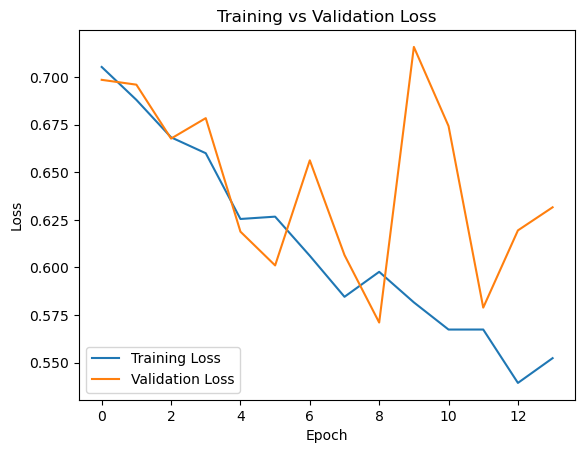

14

In [35]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


len(history.history['loss'])

### ROC

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 901ms/step


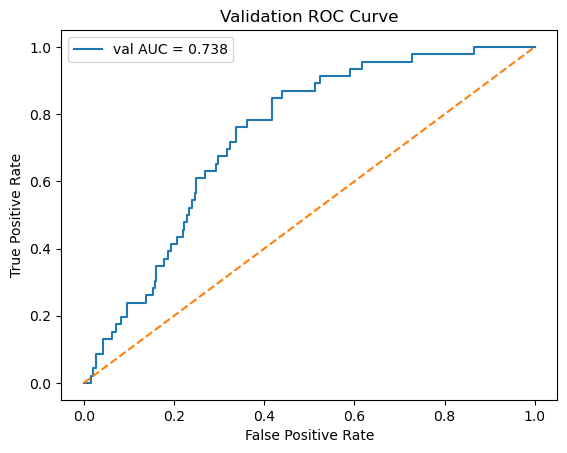

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val)[:, 1] # this is for softmax
# y_pred_prob = model.predict(X_val).ravel() # use this for sigmoid

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"val AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step


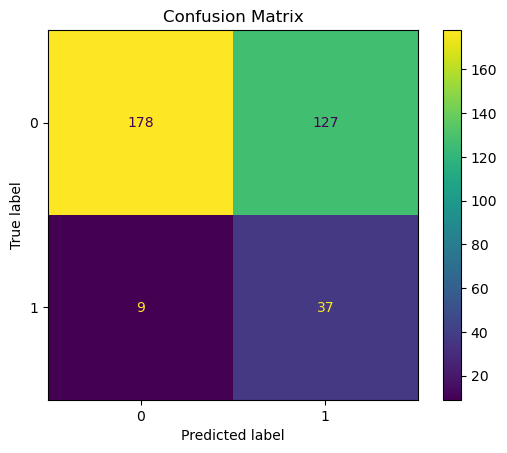

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1) # this is for softmax
# y_pred_prob = model.predict(X_val).ravel() # for sigmmoid 
# y_pred = (y_pred_prob >= 0.5).astype(int) # for sigmoid

cm = confusion_matrix(y_val, y_pred)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

## Metrics

In [38]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_val)  # convert generator output if needed
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred_classes, target_names=['non-hook', 'hook']))

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 881ms/step
              precision    recall  f1-score   support

    non-hook       0.95      0.58      0.72       305
        hook       0.23      0.80      0.35        46

    accuracy                           0.61       351
   macro avg       0.59      0.69      0.54       351
weighted avg       0.86      0.61      0.67       351



In [42]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_score = model.predict(X_val, batch_size=8)[:,1]

precision, recall, thresholds = precision_recall_curve(y_val, y_score)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step
Best threshold: 0.5663784
Precision: 0.2536231884057971
Recall: 0.7608695652173914
F1: 0.38043477885869575


In [43]:
y_pred = (y_score > best_threshold).astype(int)

# Old Model

In [15]:
# Keep only tornado cases
tornado_df = df[df['label'].isin(['tornado_hook', 'tornado_no_hook', 'non_tornadic'])].copy()

# Convert to binary labels
tornado_df['binary_label'] = tornado_df['label'].map({
    'tornado_no_hook': 0,
    # 'non_tornadic': 0,
    'tornado_hook': 1
})

print(tornado_df['binary_label'].value_counts())

binary_label
0.0    289
1.0     71
Name: count, dtype: int64


In [16]:
X_data = []
coord_data = []
y_data = []

for _, row in tornado_df.iterrows():
    s3_key = row['filepath'].replace(f's3://{bucket_name}/', '')
    frame_idx = row['frame_idx']

    try:
        with tempfile.NamedTemporaryFile(suffix='.nc', delete=True) as tmp:
            s3_client.download_file(bucket_name, s3_key, tmp.name)
            data = read_file(tmp.name, variables=variables, n_frames=4)
            coords = make_coordinates(tmp.name, frame_idx)

        xin = build_model_inputs(data, frame_idx)
        xin["coordinates"] = coords
        
        # Remove batch dimension before storing
        X_data.append({k: xin[k][0] for k in xin})
        y_data.append(row['binary_label'])

    except Exception as e:
        print("Failed:", e)
        continue

# Stack each input separately
X_stacked = {}
for key in X_data[0].keys():
    X_stacked[key] = np.stack([x[key] for x in X_data])

y_data = np.array(y_data)

# display(X_stacked)

In [17]:
from sklearn.model_selection import train_test_split

X_train = {}
X_val = {}

for key in X_stacked:
    X_train[key], X_val[key], y_train, y_val = train_test_split(
        X_stacked[key], y_data,
        test_size=0.2,
        stratify=y_data,
        random_state=42
    )

indices = np.arange(len(y_data))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_data,
    random_state=42
)

X_train = {k: v[train_idx] for k, v in X_stacked.items()}
X_val   = {k: v[val_idx]   for k, v in X_stacked.items()}

y_train = y_data[train_idx]
y_val   = y_data[val_idx]

feature_extractor = keras.Model(
    inputs=cnn.input,
    outputs=cnn.layers[-2].output
)

# Freeze most layers
for layer in feature_extractor.layers[:-15]:
    layer.trainable = False

# Unfreeze last 15 layers
for layer in feature_extractor.layers[-15:]:
    layer.trainable = True

x = feature_extractor.output

# ADD THIS:
x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(
    inputs=feature_extractor.input,
    outputs=output
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

for i, layer in enumerate(cnn.layers):
    out = layer.output
    
    if isinstance(out, list):
        shape = [o.shape for o in out]
    else:
        shape = out.shape
        
    print(i, layer.name, shape)

ValueError: Input y contains NaN.

In [ ]:
import keras

# Remove the last layer (classifier)
feature_extractor = keras.Model(
    inputs=cnn.input,
    outputs=cnn.layers[-2].output
)

for layer in feature_extractor.layers[:-3]: # was 10
    layer.trainable = False

for layer in feature_extractor.layers[-3:]: # was 10
    layer.trainable = True

x = feature_extractor.output

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(64, activation='relu')(x) # was 128
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)

output = keras.layers.Dense(2, activation='softmax')(x)

model = keras.Model(
    inputs=feature_extractor.input,
    outputs=output
)

model.compile(
    optimizer=keras.optimizers.Adam(3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(enumerate(weights))

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=8,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 328ms/step - accuracy: 0.5149 - loss: 1.0137 - val_accuracy: 0.2039 - val_loss: 1.0705
Epoch 2/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 313ms/step - accuracy: 0.5199 - loss: 0.8547 - val_accuracy: 0.3947 - val_loss: 0.8416
Epoch 3/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 299ms/step - accuracy: 0.5281 - loss: 0.9806 - val_accuracy: 0.5789 - val_loss: 0.6566
Epoch 4/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 301ms/step - accuracy: 0.4901 - loss: 0.8625 - val_accuracy: 0.6184 - val_loss: 0.6138
Epoch 5/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 312ms/step - accuracy: 0.4884 - loss: 0.9191 - val_accuracy: 0.7434 - val_loss: 0.5602
Epoch 6/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 299ms/step - accuracy: 0.5116 - loss: 0.8426 - val_accuracy: 0.7829 - val_loss: 0.5588
Epoch 7/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 298ms/step - accuracy: 0.4570 - loss: 0.8540 - val_accuracy: 0.8816 - val_loss: 0.5509
Epoch 8/40
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.5083 - loss: 0.7671 - val_accu

In [ ]:
# print(type(cnn))
# cnn.summary()

In [ ]:
print("Train hook fraction:", np.mean(y_train))
print("Val hook fraction:", np.mean(y_val))

Train hook fraction: 0.09437086092715231
Val hook fraction: 0.09210526315789473


## Plot

### Training vs Validation

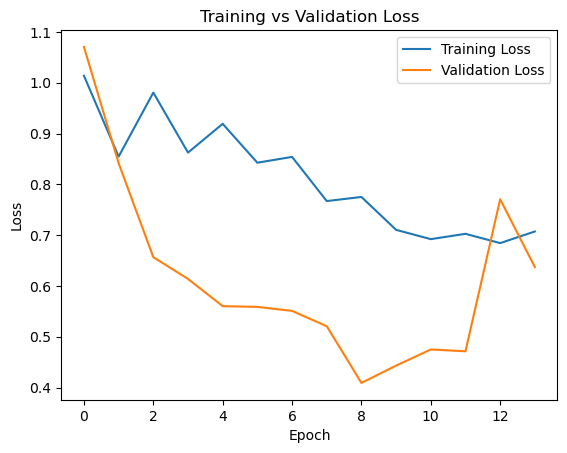

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### ROC

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 929ms/step


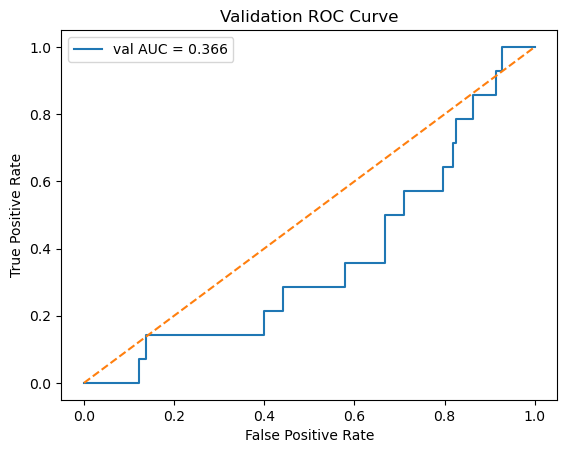

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"val AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step


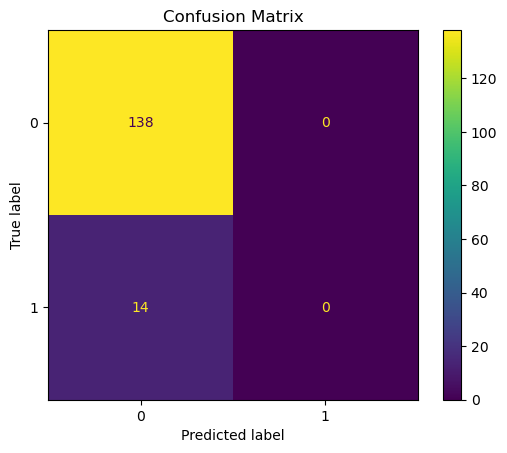

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

# NEW TRY

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):
        # Clip predictions for numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # Cross entropy
        bce = -(y_true * tf.math.log(y_pred) +
                (1 - y_true) * tf.math.log(1 - y_pred))

        # Focal scaling
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow((1 - p_t), gamma)

        return focal_weight * bce

    return loss

In [ ]:
import tensorflow as tf
from tensorflow import keras

# ── Inputs: only DBZ and VEL (2 channels each) ──────────────────────────────
dbz_input = keras.Input(shape=(None, None, 2), name='DBZ')
vel_input  = keras.Input(shape=(None, None, 2), name='VEL')

# ── Normalize ────────────────────────────────────────────────────────────────
dbz_norm = keras.layers.Normalization(name='Normalize_DBZ')(dbz_input)
vel_norm  = keras.layers.Normalization(name='Normalize_VEL')(vel_input)

# ── Concatenate (4 channels total instead of 14) ─────────────────────────────
x = keras.layers.Concatenate(name='Concatenate1')([dbz_norm, vel_norm])

# ── Replace NaNs with 0 ──────────────────────────────────────────────────────
x = keras.layers.ZeroPadding2D(padding=0)(x)  # no-op, just skip the nan line

# ── Conv block 1: 48 filters ─────────────────────────────────────────────────
x = keras.layers.Conv2D(48, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(48, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 2: 96 filters ─────────────────────────────────────────────────
x = keras.layers.Conv2D(96, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(96, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 3: 192 filters ────────────────────────────────────────────────
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Conv block 4: 384 filters ────────────────────────────────────────────────
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(384, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.2)(x)

# ── Classification head ───────────────────────────────────────────────────────
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)
output = keras.layers.Dense(1, activation='sigmoid', name='hook')(x)

model = keras.Model(inputs=[dbz_input, vel_input], outputs=output)

# model.compile(
#     optimizer=keras.optimizers.Adam(1e-4), # original was 1e-4, trying to lower learning rate for the transfer learning. Tried 1e-5 and 1e-6
#     loss='binary_crossentropy',    # sigmoid + binary is better than softmax + sparse_categorical for 2-class
#     metrics=['accuracy', keras.metrics.AUC(name='auc')]
# )

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DBZ (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VEL (InputLayer)    │ (None, None,      │          0 │ -                 │
│                     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_DBZ       │ (None, None,      │          5 │ DBZ[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Normalize_VEL       │ (None, None,      │          5 │ VEL[0][0]         │
│ (Normalization)     │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate1        │ (None, None,      │          0 │ Normalize_DBZ[0]… │
│ (Concatenate)       │ None, 4)          │            │ Normalize_VEL[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, None,      │          0 │ Concatenate1[0][… │
│ (ZeroPadding2D)     │ None, 4)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, None,      │      1,776 │ zero_padding2d_6… │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, None,      │     20,784 │ conv2d_80[0][0]   │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, None,      │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, None,      │          0 │ max_pooling2d_24… │
│ (Dropout)           │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, None,      │     41,568 │ dropout_33[0][0]  │
│                     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, None,      │     83,040 │ conv2d_82[0][0]   │
│                     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, None,      │          0 │ conv2d_83[0][0]   │
│ (MaxPooling2D)      │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, None,      │          0 │ max_pooling2d_25… │
│ (Dropout)           │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, None,      │    166,080 │ dropout_34[0][0]  │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, None,      │    331,968 │ conv2d_84[0][0]   │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, None,      │    331,968 │ conv2d_85[0][0] 

 Total params: 4,346,027 (16.58 MB)

 Trainable params: 4,345,761 (16.58 MB)

 Non-trainable params: 266 (1.05 KB)

In [ ]:
X_train_dbz = X_train['DBZ']
X_train_vel  = X_train['VEL']
X_val_dbz   = X_val['DBZ']
X_val_vel    = X_val['VEL']

# Handle NaNs before training
X_train_dbz = np.nan_to_num(X_train_dbz, nan=0.0)
X_train_vel  = np.nan_to_num(X_train_vel,  nan=0.0)
X_val_dbz   = np.nan_to_num(X_val_dbz,   nan=0.0)
X_val_vel   = np.nan_to_num(X_val_vel,   nan=0.0)

## Train only the Head

In [ ]:
print(X_train.keys())

dict_keys(['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates'])


In [ ]:
for layer in model.layers:
    if isinstance(layer, keras.layers.Conv2D):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8,
    class_weight=class_weight
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 284ms/step - accuracy: 0.5035 - auc: 0.5744 - loss: 0.0721 - val_accuracy: 0.2639 - val_auc: 0.5308 - val_loss: 0.0445
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.5139 - auc: 0.4372 - loss: 0.0843 - val_accuracy: 0.3056 - val_auc: 0.5197 - val_loss: 0.0443
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.4618 - auc: 0.4703 - loss: 0.0750 - val_accuracy: 0.7500 - val_auc: 0.5191 - val_loss: 0.0417
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.4097 - auc: 0.3702 - loss: 0.0783 - val_accuracy: 0.6389 - val_auc: 0.5049 - val_loss: 0.0422
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.5000 - auc: 0.5044 - loss: 0.0790 - val_accuracy: 0.8056 - val_auc: 0.5369 - val_loss: 0.0400
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.5347 - auc: 0.4628 - loss: 0.0821 - val_accuracy: 0.7222 - val_auc: 0.4889 - val_loss: 0.0407
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━

## Fine-tune upper layers

In [ ]:
for layer in model.layers:
    layer.trainable = True

# Freeze early layers again
for layer in model.layers[:-10]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-6),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
history2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8,
    class_weight=class_weight
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 428ms/step - accuracy: 0.4965 - auc: 0.5623 - loss: 0.0570 - val_accuracy: 0.8056 - val_auc: 0.5554 - val_loss: 0.0327
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 383ms/step - accuracy: 0.4514 - auc: 0.4661 - loss: 0.0624 - val_accuracy: 0.8056 - val_auc: 0.5468 - val_loss: 0.0328
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 414ms/step - accuracy: 0.5139 - auc: 0.5610 - loss: 0.0614 - val_accuracy: 0.8056 - val_auc: 0.5308 - val_loss: 0.0337
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 409ms/step - accuracy: 0.4965 - auc: 0.4904 - loss: 0.0684 - val_accuracy: 0.8056 - val_auc: 0.5320 - val_loss: 0.0334
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 427ms/step - accuracy: 0.4896 - auc: 0.5508 - loss: 0.0587 - val_accuracy: 0.8056 - val_auc: 0.5357 - val_loss: 0.0344
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 405ms/step - accuracy: 0.5069 - auc: 0.4907 - loss: 0.0604 - val_accuracy: 0.8056 - val_auc: 0.5413 - val_loss: 0.0354
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━

## Use AUC for early stopping

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=7,
    restore_best_weights=True
)

## old running model

In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight = {0: weights[0], 1: weights[1]}

# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_auc', mode='max', patience=7, restore_best_weights=True
# )

# history = model.fit(
#     {'DBZ': X_train_dbz, 'VEL': X_train_vel},  # separate arrays per input
#     y_train,
#     validation_data=(
#         {'DBZ': X_val_dbz, 'VEL': X_val_vel},
#         y_val
#     ),
#     epochs=50,
#     batch_size=8,
#     class_weight=class_weight,
#     callbacks=[early_stop]
# )

## Plots

### Training vs Validation Loss Curve

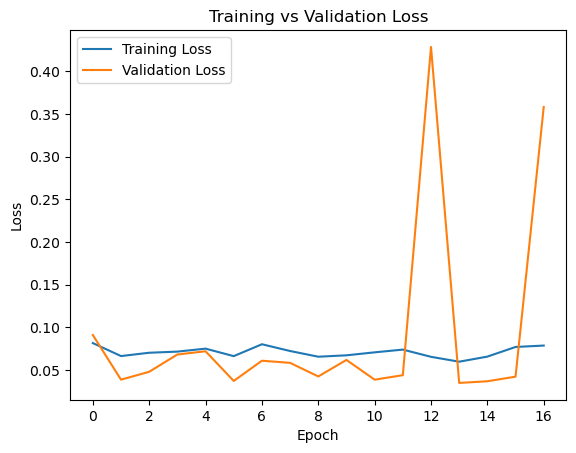

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### ROC

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step


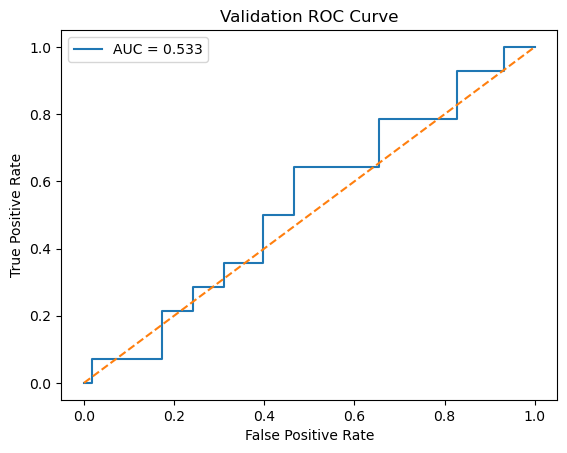

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val).ravel()

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()

plt.show()

### Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step


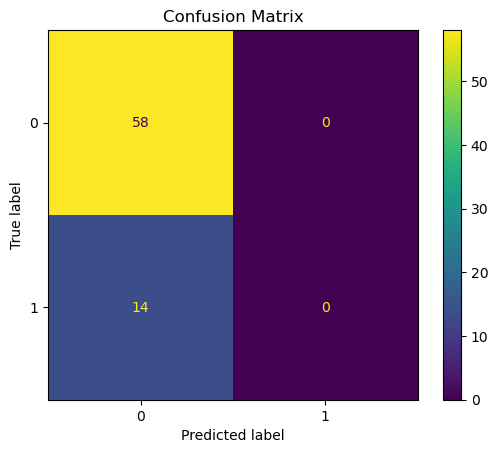

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predicted class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89        58
           1       0.00      0.00      0.00        14

    accuracy                           0.81        72
   macro avg       0.40      0.50      0.45        72
weighted avg       0.65      0.81      0.72        72


c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abchu\miniforge3\envs\MLtornado_model\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri